# Analytics Salary Predictor

This project presents an end-to-end analytics solution built using LinkedIn job posting data. It combines data analysis, machine learning, and application deployment to provide salary predictions for analytics professionals based on job characteristics such as role, experience level, work type, and location.


# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Data

In [2]:
jobs = pd.read_csv("../data/raw/postings.csv")

print(jobs.shape)
jobs.head()

(123849, 31)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


# Understand the Dataset

In [3]:
jobs.info()

jobs.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  str    
 2   title                       123849 non-null  str    
 3   description                 123842 non-null  str    
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   str    
 6   location                    123849 non-null  str    
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  str    
 12  applies                     23320 non-null   float64
 13  original_listed_time     

job_id                             0
company_name                    1719
title                              0
description                        7
max_salary                     94056
pay_period                     87776
location                           0
company_id                      1717
views                           1689
med_salary                    117569
min_salary                     94056
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                108603
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain                 39968
sponsored                          0
work_type                          0
currency                       87776
c

### Dataset contains 123,849 job postings and 31 attributes.

# Filter Analytics Jobs

In [4]:
analytics_jobs = jobs[
    jobs['title'].str.contains(
        'Data Analyst|Business Analyst|Data Scientist|Data Engineer|Machine Learning',
        case=False,
        na=False
    )
]

analytics_jobs.shape

(1742, 31)

### Filtered dataset contains analytics-related roles only.

# Top Analytics Roles

In [5]:
analytics_jobs['title'].value_counts().head(20)

title
Business Analyst                             146
Data Analyst                                 137
Data Engineer                                 90
Data Scientist                                56
Senior Data Engineer                          44
Senior Business Analyst                       34
Senior Data Analyst                           25
Machine Learning Engineer                     23
Senior Data Scientist                         21
Online Data Analyst                           20
Senior Machine Learning Engineer              19
Technical Business Analyst                    16
Lead Data Engineer                            12
Lead Data Scientist                           11
IT Business Analyst                           10
Business Data Analyst                         10
Data Engineer II                               7
Sr. Business Analyst                           7
Sr. Data Engineer                              6
Data Scientist Lead – Telematics (Remote)      6
Name: count, d

# Experience Analysis

In [6]:
analytics_jobs['formatted_experience_level'].value_counts()

formatted_experience_level
Mid-Senior level    817
Entry level         259
Associate           126
Internship           16
Director             14
Executive             3
Name: count, dtype: int64

### Most analytics jobs are not entry-level. Companies are primarily looking for candidates with prior experience.

# Work Type Analysis

In [7]:
analytics_jobs['work_type'].value_counts()

work_type
FULL_TIME     1152
CONTRACT       527
PART_TIME       27
INTERNSHIP      17
OTHER            9
TEMPORARY        7
VOLUNTEER        3
Name: count, dtype: int64

# Salary Analysis

In [8]:
analytics_jobs['normalized_salary'].describe()

count    5.420000e+02
mean     1.439723e+05
std      2.952407e+05
min      3.250000e+01
25%      9.686100e+04
50%      1.250250e+05
75%      1.621500e+05
max      6.900400e+06
Name: normalized_salary, dtype: float64

In [9]:
analytics_jobs.groupby('title')['normalized_salary'] \
              .mean() \
              .sort_values(ascending=False)

title
Vice President of Data Engineering                                       500000.000000
Data Engineer                                                            455559.238095
ML Engineer L5, LLM Application Frameworks, Machine Learning Platform    410000.000000
Machine Learning Team Lead - Artificial Intelligence                     300000.000000
Staff Data Engineer, Marketing Technology                                261100.000000
                                                                             ...      
eCommerce Data Analyst                                                             NaN
iO Data Scientist                                                                  NaN
junior java programmer/data scientist                                              NaN
 Senior ETL Data Engineer (100% Remote)                                            NaN
​Data Engineer (Fabric)​                                                           NaN
Name: normalized_salary, Length: 857,

# Location Analysis

In [10]:
analytics_jobs['location'].value_counts().head(20)

location
United States                      258
New York, NY                        63
Chicago, IL                         37
Atlanta, GA                         37
Boston, MA                          30
McLean, VA                          29
Seattle, WA                         28
San Francisco, CA                   25
Plano, TX                           25
Houston, TX                         25
Austin, TX                          24
Dallas, TX                          23
Tampa, FL                           23
Charlotte, NC                       23
Richmond, VA                        23
New York City Metropolitan Area     23
Phoenix, AZ                         21
Los Angeles, CA                     19
California, United States           18
Washington, DC                      18
Name: count, dtype: int64

### Here United States hires the most

# Skills Dataset Exploration

In [11]:
skills = pd.read_csv("../data/raw/jobs/job_skills.csv")

skills.head()

skills.columns

Index(['job_id', 'skill_abr'], dtype='str')

# Top Experience Levels

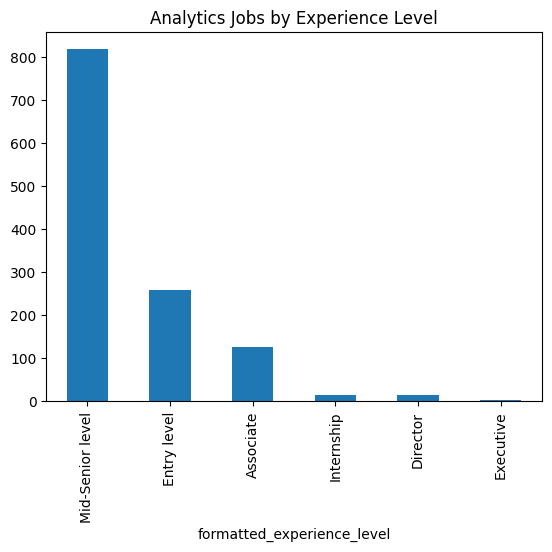

In [12]:
analytics_jobs['formatted_experience_level'] \
    .value_counts() \
    .plot(kind='bar')
plt.title('Analytics Jobs by Experience Level')
plt.show()

# Top Locations

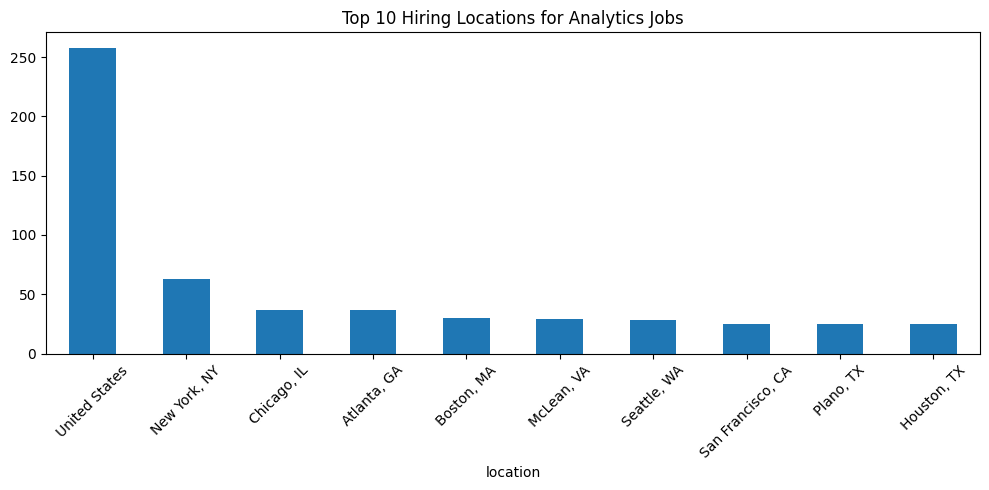

In [13]:
top_locations = analytics_jobs['location'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_locations.plot(kind='bar')
plt.title('Top 10 Hiring Locations for Analytics Jobs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Work Types

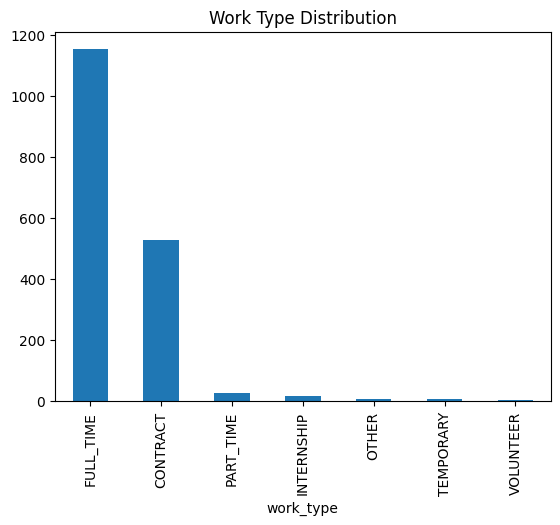

In [14]:
analytics_jobs['work_type'] \
    .value_counts() \
    .plot(kind='bar')
plt.title('Work Type Distribution')
plt.show()

### Key Findings
1. Mid-Senior roles dominate the analytics market.
2. Entry-level positions are much fewer than experienced roles.
3. Full-time jobs dominate, but contract analytics jobs are surprisingly common.
4. Hiring is concentrated in major US tech/business hubs.

# Load job skills

In [15]:
skills = pd.read_csv("../data/raw/jobs/job_skills.csv")

print(skills.shape)
print(skills.head())

(213768, 2)
       job_id skill_abr
0  3884428798      MRKT
1  3884428798        PR
2  3884428798       WRT
3  3887473071      SALE
4  3887465684       FIN


# Load skill mapping

In [16]:
skill_map = pd.read_csv("../data/raw/mappings/skills.csv")

print(skill_map.shape)
print(skill_map.head())
print(skill_map.columns.tolist())

(35, 2)
  skill_abr          skill_name
0       ART        Art/Creative
1      DSGN              Design
2      ADVR         Advertising
3      PRDM  Product Management
4      DIST        Distribution
['skill_abr', 'skill_name']


In [17]:
skills_full = skills.merge(skill_map, on='skill_abr', how='left')

print(skills_full.head())

       job_id skill_abr        skill_name
0  3884428798      MRKT         Marketing
1  3884428798        PR  Public Relations
2  3884428798       WRT   Writing/Editing
3  3887473071      SALE             Sales
4  3887465684       FIN           Finance


In [18]:
top_skills = skills_full['skill_name'].value_counts().head(20)

print(top_skills)

skill_name
Information Technology    26137
Sales                     22475
Management                20861
Manufacturing             18185
Health Care Provider      17369
Business Development      14290
Engineering               13009
Other                     12608
Finance                    8540
Marketing                  5525
Accounting/Auditing        5461
Administrative             4860
Customer Service           4292
Project Management         3997
Analyst                    3858
Research                   2986
Human Resources            2647
Legal                      2371
Consulting                 2338
Education                  2290
Name: count, dtype: int64


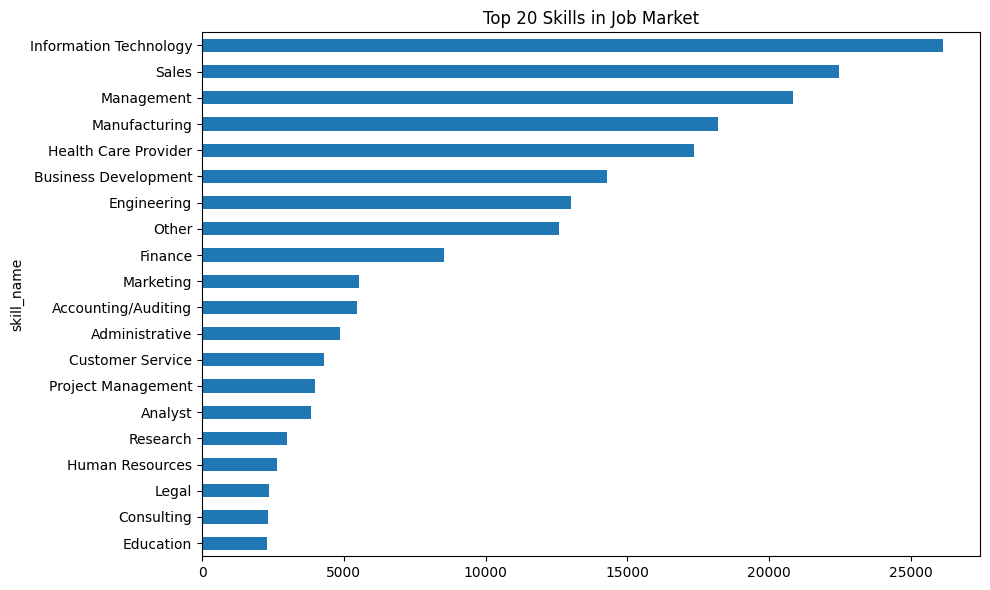

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
top_skills.sort_values().plot(kind='barh')
plt.title('Top 20 Skills in Job Market')
plt.tight_layout()
plt.show()

In [20]:
analytics_skills = skills_full.merge(
    analytics_jobs[['job_id']],
    on='job_id',
    how='inner'
)

print(analytics_skills.shape)

(3015, 3)


In [21]:
analytics_top_skills = (
    analytics_skills['skill_name']
    .value_counts()
    .head(20)
)

print(analytics_top_skills)

skill_name
Information Technology    1308
Analyst                    493
Engineering                421
Research                   316
Business Development        73
Other                       66
Sales                       55
Finance                     36
Consulting                  32
Project Management          24
Strategy/Planning           24
Product Management          20
Quality Assurance           19
General Business            16
Marketing                   16
Management                  16
Science                     16
Administrative              15
Human Resources              9
Accounting/Auditing          9
Name: count, dtype: int64


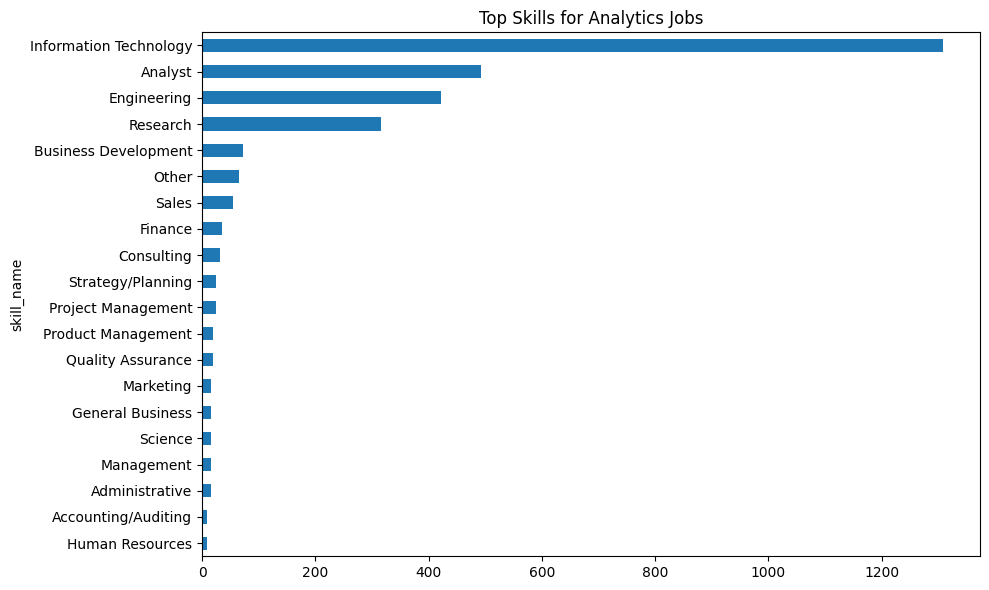

In [22]:
plt.figure(figsize=(10,6))
analytics_top_skills.sort_values().plot(kind='barh')
plt.title('Top Skills for Analytics Jobs')
plt.tight_layout()
plt.show()

In [23]:
analytics_jobs[['title','skills_desc','description']].head(5)

,title,skills_desc,description
283,Sr Data Engineer with Kafka,NaN,Data Engineer with Kafka (W2 Only)💯% Remote\nM...
325,Technical Business Analyst,NaN,We’re actively seeking a Technical Business An...
360,Cloud Platform/ Big Data Engineer,NaN,About Subaru Research and Development:Do you c...
367,Data Engineer/ETL,NaN,"Responsibilities:Develop new features, fix bug..."
389,Data Analyst,NaN,Job Title: Data AnalystDuration: ContractLocat...


# Extract Technology Skills

## Define Skills Dictionary

In [24]:
tech_skills = [
    'Python',
    'SQL',
    'Power BI',
    'Tableau',
    'Excel',
    'R',
    'AWS',
    'Azure',
    'Snowflake',
    'Databricks',
    'Spark',
    'Kafka',
    'ETL',
    'Machine Learning',
    'Deep Learning',
    'TensorFlow',
    'PyTorch',
    'Pandas',
    'NumPy',
    'Hadoop',
    'Airflow',
    'Git',
    'Docker',
    'Kubernetes'
]

## Count Skill Mentions

In [25]:
import re

skill_counts = {}

for skill in tech_skills:
    
    if skill == 'R':
        count = analytics_jobs['description'].str.contains(
            r'\bR\b',
            regex=True,
            case=False,
            na=False
        ).sum()
    else:
        count = analytics_jobs['description'].str.contains(
            skill,
            case=False,
            na=False
        ).sum()

    skill_counts[skill] = count

print(skill_counts)

{'Python': np.int64(782), 'SQL': np.int64(890), 'Power BI': np.int64(166), 'Tableau': np.int64(211), 'Excel': np.int64(913), 'R': np.int64(250), 'AWS': np.int64(473), 'Azure': np.int64(275), 'Snowflake': np.int64(146), 'Databricks': np.int64(119), 'Spark': np.int64(292), 'Kafka': np.int64(79), 'ETL': np.int64(230), 'Machine Learning': np.int64(446), 'Deep Learning': np.int64(110), 'TensorFlow': np.int64(98), 'PyTorch': np.int64(110), 'Pandas': np.int64(52), 'NumPy': np.int64(42), 'Hadoop': np.int64(120), 'Airflow': np.int64(80), 'Git': np.int64(371), 'Docker': np.int64(73), 'Kubernetes': np.int64(78)}


## Convert to DataFrame

In [26]:
skill_df = pd.DataFrame(
    skill_counts.items(),
    columns=['Skill', 'Count']
)

skill_df = skill_df.sort_values(
    by='Count',
    ascending=False
)

print(skill_df)

               Skill  Count
4              Excel    913
1                SQL    890
0             Python    782
6                AWS    473
13  Machine Learning    446
21               Git    371
10             Spark    292
7              Azure    275
5                  R    250
12               ETL    230
3            Tableau    211
2           Power BI    166
8          Snowflake    146
19            Hadoop    120
9         Databricks    119
14     Deep Learning    110
16           PyTorch    110
15        TensorFlow     98
20           Airflow     80
11             Kafka     79
23        Kubernetes     78
22            Docker     73
17            Pandas     52
18             NumPy     42


## Visualize

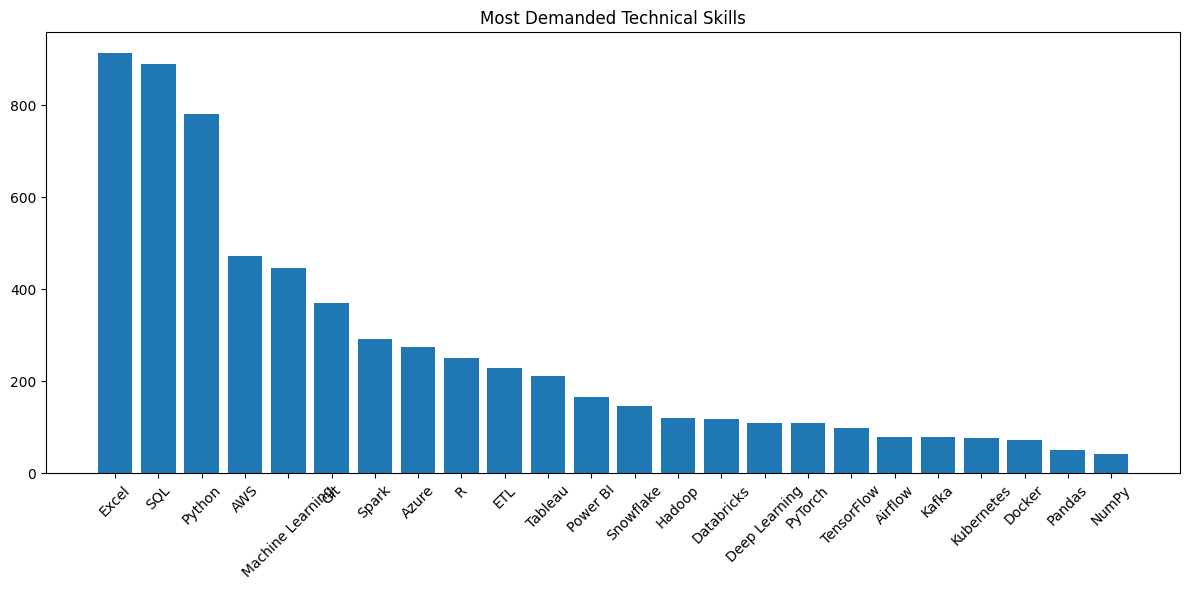

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    skill_df['Skill'],
    skill_df['Count']
)

plt.xticks(rotation=45)

plt.title("Most Demanded Technical Skills")

plt.tight_layout()

plt.show()

# Skill vs Salary

In [28]:
salary_skill = []

for skill in tech_skills:
    
    skill_jobs = analytics_jobs[
        analytics_jobs['description'].str.contains(
            skill,
            case=False,
            na=False
        )
    ]
    
    avg_salary = skill_jobs['normalized_salary'].median()
    
    salary_skill.append([skill, avg_salary])

salary_skill_df = pd.DataFrame(
    salary_skill,
    columns=['Skill', 'Median Salary']
)

salary_skill_df.sort_values(
    by='Median Salary',
    ascending=False,
    inplace=True
)

salary_skill_df.head(15)

,Skill,Median Salary
16,PyTorch,174500.00
14,Deep Learning,172150.00
18,NumPy,170000.00
17,Pandas,170000.00
15,TensorFlow,167500.00
13,Machine Learning,162100.00
23,Kubernetes,159000.00
11,Kafka,150936.75
20,Airflow,146250.00
22,Docker,145200.00


## Top Analytics Job Titles Chart

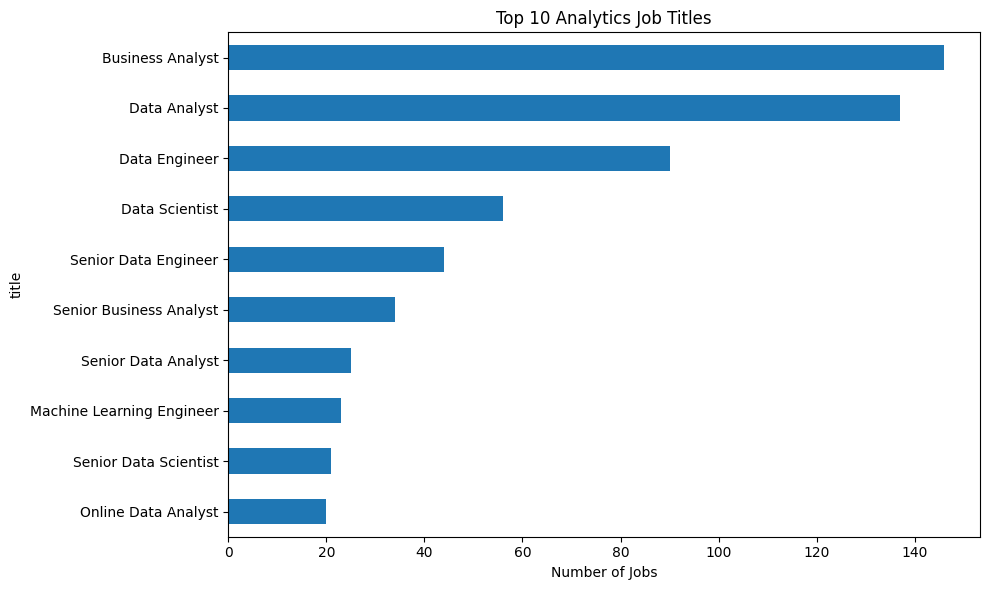

In [29]:
top_roles = analytics_jobs['title'].value_counts().head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
top_roles.sort_values().plot(kind='barh')

plt.title('Top 10 Analytics Job Titles')
plt.xlabel('Number of Jobs')

plt.tight_layout()
plt.show()

### Observation

Data Analyst, Business Analyst, Data Engineer, and Data Scientist
are among the most frequently advertised analytics-related roles.

## Demand vs Salary Scatter Plot

In [30]:
combined = pd.merge(
    skill_df,
    salary_skill_df,
    on='Skill'
)

combined.head()

,Skill,Count,Median Salary
0,Excel,913,119050.0
1,SQL,890,130000.0
2,Python,782,141500.0
3,AWS,473,140200.0
4,Machine Learning,446,162100.0


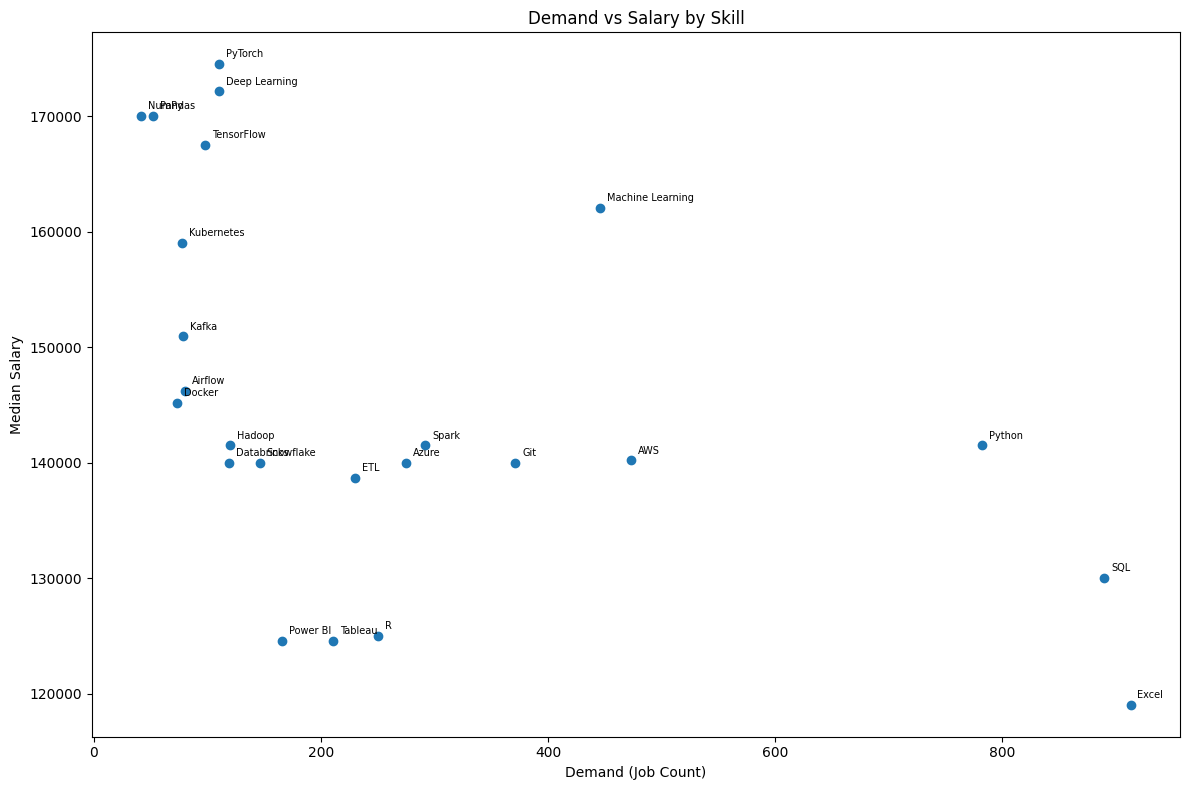

In [31]:
plt.figure(figsize=(12,8))

plt.scatter(
    combined['Count'],
    combined['Median Salary']
)

for _, row in combined.iterrows():
    plt.annotate(
        row['Skill'],
        (row['Count'], row['Median Salary']),
        xytext=(5,5),
        textcoords='offset points',
        fontsize=7
    )

plt.xlabel('Demand (Job Count)')
plt.ylabel('Median Salary')
plt.title('Demand vs Salary by Skill')

plt.tight_layout()
plt.show()

### Observation

SQL, Python, and Excel show strong demand across analytics roles,
while Machine Learning and Deep Learning related skills tend to
command higher salaries.

# Key Insights

## Hiring Trends
- Mid-Senior level positions dominate the analytics job market.
- Full-time roles account for the majority of analytics opportunities.

## Most Demanded Skills
- Excel
- SQL
- Python
- AWS
- Machine Learning

## Highest Paying Skills
- PyTorch ($174,500 median salary)
- Deep Learning ($172,150 median salary)
- TensorFlow ($167,500 median salary)
- Machine Learning ($162,100 median salary)

## Geographic Trends
- New York, Chicago, Atlanta, and Boston are among the leading hiring locations for analytics professionals.

# Conclusion

This project analyzed 123,849 LinkedIn job postings and identified 2,098 analytics-related roles.

Key findings indicate that:
- Mid-Senior level positions dominate the analytics market.
- Full-time employment is the most common work arrangement.
- Excel, SQL, and Python remain the most demanded skills.
- AI and Machine Learning technologies such as PyTorch, TensorFlow, and Deep Learning are associated with the highest salaries.
- Major hiring hubs include New York, Chicago, Atlanta, and Boston.

These insights can help aspiring data professionals prioritize skill development and understand current job market trends.

In [32]:
import os

os.makedirs("../data/processed", exist_ok=True)

analytics_jobs.to_csv(
    "../data/processed/analytics_jobs.csv",
    index=False
)

skill_df.to_csv(
    "../data/processed/skill_frequency.csv",
    index=False
)

salary_skill_df.to_csv(
    "../data/processed/skill_salary.csv",
    index=False
)

print("Files exported successfully!")

Files exported successfully!


In [33]:
analytics_jobs[
    ['title',
     'formatted_experience_level',
     'work_type',
     'location',
     'normalized_salary']
].isnull().sum()

title                            0
formatted_experience_level     507
work_type                        0
location                         0
normalized_salary             1200
dtype: int64

In [34]:
model_df = analytics_jobs[
    ['title',
     'formatted_experience_level',
     'work_type',
     'location',
     'normalized_salary']
].dropna()

print(model_df.shape)

(435, 5)
